# Introduction

Citibike is the leading bikesharing platform in New York, including the districts of Manhattan, Brooklyn, Queens & Jersey City. That said, the company is far from being profitable due to growing competition from other modes of transportation (e.g., scooters, electric bikes, etc.). According to a consulting firm hired a few months ago, the operations of Citibike are inefficient due to the lack of data-driven decision processes. If Citibike were only 4\% more efficient, it would become profitable. During peak hours (e.g., morning commute time), the bikesharing platform is particularly unreliable. Approximately 20\% of the dock stations face a "stock-out" situation, meaning that there are no bikes available. In such cases, commuters choose other modes of transportation. 

<img src="citi-bike.jpg" width="500">

The consulting firm recommends using **optimization models** to improve the operations, especially during peak time. As part of this new strategy, you are recently hired as a lead data scientist of Citibike. You suspect that the inventory of bikes and the dock stations are not well positioned given the incoming demand at peak times. In this workshop, you will develop a data-driven optimization model to improve the positioning of inventory at peak time. In particular, you will formulate and implement integer programming models.

*Workshop instructions*: **Please carefully read all the instructions below:**
- The code cells are partially filled. You need to complete and execute the code in each cell. *You can consult any material posted on Canvas to help you get started with the syntax. You can ask questions to the TAs and discuss with your teammates.*
- Make sure to answer all the questions along the way in a detailed manner.
- This is an individual assignment; you should differentiate your coding style, answers, commenting, etc. from those of your teammates.
- Only Q1-Q3.6 are meant to be covered in class. You are free to start working on the other questions, but you should not exchange with your teammates on all remaining questions.

*Submission*: Your submission should include the following:
- *Notebook:* An html file along with a .ipynb file **(85 pt)**
- *Executive summary:* A 1 pager report summarizing all your findings (at least 11 pt font, 1 inch margin, pdf/doc format). This report should take the form of an executive summary that combines elements of your analysis and business recommendations. Supporting evidence can be provided in an appendix, or by referencing the questions of the workshop. The report will be evaluated along 3 dimensions: clarity, scientific validity, practical relevance. **(15 pt)**


# Visualize the data

## Load the data

Your colleague has generated data sets that contains all the needed information about the demand and available inventory of bikes during *one hour at peak time*. Your initial analysis will be based on the following data sets:

- `demand.csv`: describes the number of bikes rented at each dock station (during one peak hour),
- `starting_inventory.csv`: describes the initial inventory of bikes at each dock station (before peak hour),
- `distances.csv`: describes the distance between any two dock stations (in km unit).


Ideally, the inventory of bikes available the beginning of the peak hour should approximately match the expected amount of demand. For example, if you expect 5 user requests in station A, and 5 user requests in station B in the next hour, the number of bikes in station A and B should be roughly equal, otherwise there is an imbalance of inventory. Using spatial visualization, you will check if the initial inventory is balanced or imbalanced.

In [4]:
!pip install folium

In [1]:
# Import various packages
import pandas as pd
import numpy as np
import folium # visualisation package for spatial data (plot of maps)
import seaborn as sns # general visualization package 
import matplotlib.pyplot as plt # general visualization package 
#next command allows you to display the figures in the notebook
%matplotlib inline     

In [ ]:
## In case folium is not installed, run the command below and import folium again
# ! conda install -c conda-forge folium --yes

In [3]:
starting_inventory = pd.read_csv("starting_inventory.csv", index_col=0) 
# "index_col=0" is used so that the dataframe is indexed by the first column, which is the dock station ID
demand = pd.read_csv("demand.csv", index_col=0)
distances = pd.read_csv("distances.csv", index_col=0)
distances.columns = list(map(lambda x: int(x),distances.columns.tolist())) # the column names (dock IDs) are converted into integers
replenishment = pd.read_csv("replenishment.csv", index_col=0)

In [5]:
# Insert your code here
starting_inventory.describe()

,count,latitude,longitude
count,689.000000,689.000000,689.000000
mean,30.724238,40.732527,-73.967780
std,70.308432,0.041163,0.024024
min,10.000000,40.655400,-74.025353
25%,10.000000,40.695807,-73.987030
50%,10.000000,40.728419,-73.968044
75%,19.000000,40.767100,-73.949450
max,739.000000,40.814394,-73.910651


In [7]:
starting_inventory.head()

,count,latitude,longitude
station_id,,,
119,18,40.696089,-73.978034
120,10,40.686768,-73.959282
127,54,40.731724,-74.006744
143,63,40.692395,-73.993379
144,15,40.698399,-73.980689


In [9]:
demand.describe()

,latitude,longitude,count
count,689.000000,689.000000,689.000000
mean,40.732527,-73.967780,27.648766
std,0.041163,0.024024,56.377839
min,40.655400,-74.025353,1.000000
25%,40.695807,-73.987030,5.000000
50%,40.728419,-73.968044,10.000000
75%,40.767100,-73.949450,26.000000
max,40.814394,-73.910651,428.000000


In [11]:
demand.head()

,latitude,longitude,count
station_id,,,
119,40.696089,-73.978034,10
120,40.686768,-73.959282,6
127,40.731724,-74.006744,134
143,40.692395,-73.993379,34
144,40.698399,-73.980689,10


In [13]:
replenishment.describe()

,latitude,longitude,count
count,689.000000,689.000000,689.000000
mean,9.869376,-17.764877,6.513788
std,1.136245,2.045241,11.240249
min,0.000000,-18.000000,0.000000
25%,10.000000,-18.000000,1.000000
50%,10.000000,-18.000000,3.000000
75%,10.000000,-18.000000,7.000000
max,10.000000,0.000000,108.000000


In [15]:
replenishment.head()

,latitude,longitude,count
station_id,,,
119,10,-18,1
120,10,-18,2
127,10,-18,42
143,10,-18,3
144,10,-18,1


In [17]:
distances.describe()

,119,120,127,143,144,146,150,157,161,167,...,534,536,539,540,545,546,72,79,82,83
count,689.000000,689.000000,689.000000,689.000000,689.000000,689.000000,689.000000,689.000000,689.000000,689.000000,...,689.000000,689.000000,689.000000,689.000000,689.000000,689.000000,689.000000,689.000000,689.000000,689.000000
mean,5.234788,5.818614,5.660433,5.815784,5.173995,5.896868,4.557984,6.009891,5.136558,4.691174,...,6.487351,4.529948,4.646942,4.676314,4.500302,4.725332,5.935885,5.695771,5.451519,5.886057
std,3.101918,3.240807,2.416317,3.396272,3.039626,2.765462,2.232180,3.456671,2.369193,2.011353,...,3.129782,1.880601,2.148153,2.001787,1.912251,2.026796,2.523133,2.677876,2.832379,3.535927
min,0.000000,0.000000,0.000000,0.000135,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.778453,3.166575,3.980364,2.922870,2.795046,3.792634,2.907156,3.077351,3.575707,3.018884,...,3.896037,3.009274,3.131241,3.093796,2.985554,3.137539,4.043380,3.715493,3.254939,3.078088
50%,4.243954,5.492614,5.792542,5.194791,4.199160,5.789344,4.364615,5.426828,5.290044,4.733095,...,6.257024,4.590299,4.426917,4.846375,4.599683,4.905780,5.945542,5.633804,5.191993,5.067243
75%,7.926693,8.437574,7.444620,8.712969,7.752457,7.900162,5.982674,8.953698,6.833613,6.320707,...,8.895602,6.124998,6.031318,6.364107,6.043458,6.460421,8.018556,7.575516,7.511705,8.959315
max,12.087375,12.776908,10.356681,12.864326,11.919733,11.534052,9.753680,13.111354,9.844240,9.969009,...,12.871711,9.299113,9.929280,9.222172,8.738407,9.322635,11.311183,11.157840,11.482100,13.259187


In [19]:
distances.head()

,119,120,127,143,144,146,150,157,161,167,...,534,536,539,540,545,546,72,79,82,83
location_id,,,,,,,,,,,,,,,,,,,,,
119,0.000000,2.094147,4.576156,1.578340,0.351894,3.703925,2.494454,1.882099,3.869203,5.284849,...,3.528586,4.543318,2.622010,4.720622,4.041264,4.861771,7.293577,3.674261,2.678328,1.238214
120,2.094147,0.000000,6.537415,3.455861,2.436309,5.789344,4.035755,3.707200,5.748911,6.435531,...,5.572353,5.699120,2.859642,6.081263,5.317338,6.238080,8.764337,5.737332,4.761456,1.729366
127,4.576156,6.537415,0.000000,4.153819,4.230192,1.565336,2.806855,4.219027,0.901155,3.517445,...,2.978002,3.285418,4.930235,2.710110,2.904528,2.690806,3.778741,1.260900,2.157752,5.674226
143,1.578340,3.455861,4.153819,0.000135,1.403859,2.857265,3.110962,0.312868,3.707730,5.910346,...,2.184809,5.225369,4.031096,5.194791,4.668016,5.307196,7.487916,2.984197,1.996774,1.908738
144,0.351894,2.436309,4.230192,1.403859,0.000000,3.355853,2.247528,1.716283,3.535663,5.071439,...,3.230217,4.337345,2.655934,4.474058,3.819127,4.610999,7.013423,3.322657,2.329233,1.521284


In [21]:
print(replenishment.isna().sum())
print(demand.isna().sum())
print(starting_inventory.isna().sum())
print(distances.isna().sum())

latitude     0
longitude    0
count        0
dtype: int64
latitude     0
longitude    0
count        0
dtype: int64
count        0
latitude     0
longitude    0
dtype: int64
119    0
120    0
127    0
143    0
144    0
      ..
546    0
72     0
79     0
82     0
83     0
Length: 689, dtype: int64


## Plot the heatmaps of demand and inventory

In the next cells, we will generate a heatmap of New York, representing the level of demand in different regions.

In [27]:
def generateBaseMap(default_location=[40.71, -73.96], default_zoom_start=12.5):
    '''
    This function generates a base map using the folium package
    
    Arguments:
    default_location -> latitude, longitude (a list)
    default_zoom_start -> level of zoom of the map (a positive number)
    '''
    base_map = folium.Map(location=default_location,control_scale=True, zoom_start=default_zoom_start)
    # 'Stamen Toner' is a type of map; by default the map is "OpenStreetMap"
    return base_map

The next cell will plot a heatmap of the demand.

In [29]:
# Import the HeatMap object constructor from the folium package
from folium.plugins import HeatMap 

# To begin, generate a base map, which will be edited next
base_map = generateBaseMap()

# The demand is converted into a list of t-uples, each describing one request point: (longitude, latitude, count)
# Copy the demand dataframe 
demand_agg = demand.copy()
# Rounding latitudes and longitudes to nearest 0.001 decimal
demand_agg.loc[:,['latitude', 'longitude']] = demand_agg.loc[:,['latitude', 'longitude']].round(3)
# Aggregating by latitude and longitude 
demand_agg= demand_agg[['latitude', 'longitude', 'count']].groupby(['latitude', 'longitude']).sum()
# Converting demand into a list
demand_list = demand_agg.reset_index().values.tolist()

# Add the desired heatmap to the base map
HeatMap(data= demand_list,radius=0, max_zoom=15,minOpacity=0).add_to(base_map)
base_map

To understand how well the initial inventory of bikes matches the expected demand at docking stations, it's helpful to visualize how bikes are distributed across the city at the start of the day. This involves creating a heatmap that shows the number of bikes available at each station based on the starting_inventory data. This visualization builds on the earlier demand heatmap by modifying the relevant parts of the code to reflect the initial bike supply instead of demand.

In [31]:
from folium.plugins import HeatMap
base_map = generateBaseMap()
inventory_agg = starting_inventory.copy()
inventory_agg.loc[:,['latitude', 'longitude']] = inventory_agg.loc[:,['latitude', 'longitude']].round(3)
# Aggregating by latitude and longitude 
inventory_agg= inventory_agg[['latitude', 'longitude', 'count']].groupby(['latitude', 'longitude']).sum()
# Converting demand into a list
inventory_list = inventory_agg.reset_index().values.tolist()
HeatMap(data= inventory_list,radius=0, max_zoom=15,minOpacity=0).add_to(base_map)
base_map

*There are changes in the heatmap. In the center, there is mismatch in the demand and the starting inventory. The demand is also concentrated in the center, but the inventory is not concentrated in the center.* 



Defining two new metrics that quantify the imbalance between demand inventory and reuse the same code as above: 
- The first metric could capture the deficit of inventory at the stations where demand_agg > inventory_agg,
- The second metric could capture the excess of inventory at the stations where inventory_agg > demand_agg.

In [33]:
base_map = generateBaseMap()
deficit = np.maximum(0, demand_agg - inventory_agg)
deficit_list = deficit.fillna(0).reset_index().values.tolist()
HeatMap(data= deficit_list,radius=0, max_zoom=15,minOpacity=0).add_to(base_map)
base_map

In [67]:
base_map = generateBaseMap()
excess = np.maximum(0, inventory_agg - demand_agg)
excess_list = excess.fillna(0).reset_index().values.tolist()
HeatMap(data= excess_list,radius=0, max_zoom=15,minOpacity=0).add_to(base_map)
base_map

C:\Users\dell\AppData\Local\Temp\ipykernel_22976\3948769590.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df["count_demand"], label="Demand", shade=True, color="red")
C:\Users\dell\AppData\Local\Temp\ipykernel_22976\3948769590.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df["count_inventory"], label="Inventory", shade=True, color="blue")


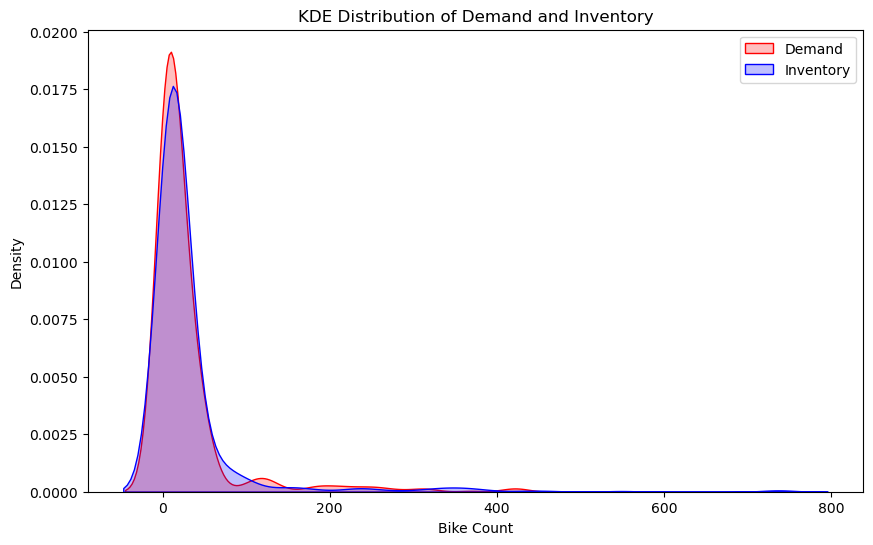

In [40]:
# Insert your code here
df = demand.merge(starting_inventory, on="station_id", suffixes=("_demand", "_inventory"))

# Plot histogram
plt.figure(figsize=(10, 6))
sns.kdeplot(df["count_demand"], label="Demand", shade=True, color="red")
sns.kdeplot(df["count_inventory"], label="Inventory", shade=True, color="blue")
plt.xlabel("Bike Count")
plt.ylabel("Density")
plt.title("KDE Distribution of Demand and Inventory")
plt.legend()
plt.show()

The plot shows the distribution of bike demand (red) and inventory (blue). Both distributions are heavily skewed to the right, indicating that most values are concentrated at lower bike counts, with occasional higher values. The close overlap suggests that inventory levels closely match demand, but minor deviations exist at higher values.

# Optimal Rebalancing of Bike Inventory

**Matching supply with demand**: Given the imbalances between demand and inventory, Citibike runs frequent "rebalancing" operations, where bikes are relocated from a dock station having an excess of inventory to a station having insufficient inventory. These rebalancing operations are run in an ad-hoc fashion. You would like to construct an optimization model to rigorously rebalance the inventory before the beginning of the peak hour.

**The economics of rebalancing:** Rebalancing operators have to be paid \\$1 per km per relocated bike. There are no geographical restrictions on the rebalancing of bikes (from any station to any other station). After the rebalancing is performed, the amount of demand satisfied at each station will the minimum between the new initial inventory level and the total demand (we assume that there is no further replenishment during the peak hour). Each satisfied user request brings \\$4 of revenue, on average. Hence, when bikes are unavailable and user requests are unfulfilled, Citibike loses the revenue opportunity of \\$4 per user. 

*The next step involves framing the bike rebalancing challenge as an integer programming problem. Using the current inventory levels provided in starting_inventory, the goal is to determine how bikes should be relocated across stations to maximize the total net revenue. For the sake of simplicity, it's assumed that all rebalancing actions occur instantly before the start of the peak hour, and no additional bikes are added to the system during this time.*

In [48]:
# The following lines of code import the gurobi package
import gurobipy as gp
from gurobipy import GRB,quicksum

## Model creation

### Q2.1. Create a GUROBI new model "m", named "rebalancing"

In [50]:
m = gp.Model("rebalancing")

Set parameter Username
Academic license - for non-commercial use only - expires 2026-01-08


## Decision variables

In [52]:
# Instantiate the list of all stations
stations = demand.index.tolist()

# Next, we create am "integer" decision variable for each pair of dock stations (A,B)
relocation = m.addVars(stations,stations,vtype=GRB.INTEGER, lb = 0, name="relocation")

*The above code adds decision variables x<sub>s1, s2</sub> which indicates the number of bikes to be relocated from s1 to s2. <br/>
x<sub>s1, s2</sub> is an Integer variable*


In [54]:
satisfied_demand = m.addVars(stations,vtype=GRB.INTEGER, lb = 0, name="satisfied_demand")

*The satisfied_demand variables are needed because they help model how much of the demand at each station is actually met after the rebalancing process. Without these variables, we would only track the relocation of bikes but not the actual effectiveness of meeting demand at each station.*


## Constraints

In [56]:
for s1 in stations:
    m.addConstr(quicksum(relocation[s1, s] for s in stations) <= starting_inventory.loc[s1, "count"])

The satisfied demand in each station is the minimum between the demand and the inventory after rebalancing. For example, if station A has 10 bikes before the relocation and we relocate 2 extra bikes, we can satisfy up to 12 users. If the demand at station A is 8, we satisfy all 8 users. If the demand at station A is 15, we can only satisfy 12 users, and we lose 3 user requests. In general, we have the equation:

$$ {\rm satisfiedDemand}(A) ={\rm minimum} \left\{ {\rm InventoryAfterRebalancing}(A), {\rm Demand}(A)\right\}$$

Below, you will add two ensembles of constraints to our model `m` to capture the notion of satisfied demand.

### Adding constraints imposing that `satisfied_demand` is smaller or equal to the demand, in each station.

In [58]:
for s in stations:
    m.addConstr(satisfied_demand[s] <= demand.loc[s, "count"])

*The below constraint is adding a condition on the satisfied_demand is less than the inventory after relocation.*



In [60]:
# Additional constraints
m.addConstrs((satisfied_demand[i] <= starting_inventory.loc[i,"count"] \
              + quicksum(relocation[j,i] for j in stations) -quicksum(relocation[i,j] for j in stations)
                  for i in stations),name = "satisfied_demand_vs_inventory_after_rebalancing")

{119: <gurobi.Constr *Awaiting Model Update*>,
 120: <gurobi.Constr *Awaiting Model Update*>,
 127: <gurobi.Constr *Awaiting Model Update*>,
 143: <gurobi.Constr *Awaiting Model Update*>,
 144: <gurobi.Constr *Awaiting Model Update*>,
 146: <gurobi.Constr *Awaiting Model Update*>,
 150: <gurobi.Constr *Awaiting Model Update*>,
 157: <gurobi.Constr *Awaiting Model Update*>,
 161: <gurobi.Constr *Awaiting Model Update*>,
 167: <gurobi.Constr *Awaiting Model Update*>,
 173: <gurobi.Constr *Awaiting Model Update*>,
 174: <gurobi.Constr *Awaiting Model Update*>,
 195: <gurobi.Constr *Awaiting Model Update*>,
 2000: <gurobi.Constr *Awaiting Model Update*>,
 2002: <gurobi.Constr *Awaiting Model Update*>,
 2003: <gurobi.Constr *Awaiting Model Update*>,
 2005: <gurobi.Constr *Awaiting Model Update*>,
 2009: <gurobi.Constr *Awaiting Model Update*>,
 2012: <gurobi.Constr *Awaiting Model Update*>,
 2017: <gurobi.Constr *Awaiting Model Update*>,
 2021: <gurobi.Constr *Awaiting Model Update*>,
 2022

## Objective

In [62]:
m.setObjective(4*quicksum(satisfied_demand[s] for s in stations) - quicksum(relocation[s1, s2]*distances[s1][s2] for s1 in stations for s2 in stations), GRB.MAXIMIZE)

## Solve

In [64]:
def printSolution():
    if m.status == GRB.OPTIMAL:
        print('\nNet revenue: %g' % m.objVal)
    else:
        print('No solution:', m.status)
        
m.optimize()
printSolution()

Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i5-1035G1 CPU @ 1.00GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 2067 rows, 475410 columns and 1424163 nonzeros
Model fingerprint: 0x705b3843
Variable types: 0 continuous, 475410 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e-04, 2e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 7e+02]
Found heuristic solution: objective 62468.000000
Presolve removed 689 rows and 689 columns (presolve time = 5s) ...
Presolve removed 729 rows and 20018 columns (presolve time = 10s) ...
Presolve removed 689 rows and 19978 columns
Presolve time: 10.38s
Presolved: 1378 rows, 455432 columns, 1337358 nonzeros
Variable types: 0 continuous, 455432 integer (6671 binary)
Found heuristic solution: objective 62739.189353
Deterministic con

In [66]:
from collections import namedtuple
def get_bearing(p1, p2):
    
    '''
    Returns compass bearing from p1 to p2
    
    Parameters
    p1 : namedtuple with lat lon
    p2 : namedtuple with lat lon
    
    Return
    compass bearing of type float
    
    Notes
    Based on https://gist.github.com/jeromer/2005586
    '''
    
    long_diff = np.radians(p2.lon - p1.lon)
    
    lat1 = np.radians(p1.lat)
    lat2 = np.radians(p2.lat)
    
    x = np.sin(long_diff) * np.cos(lat2)
    y = (np.cos(lat1) * np.sin(lat2) 
        - (np.sin(lat1) * np.cos(lat2) 
        * np.cos(long_diff)))
    bearing = np.degrees(np.arctan2(x, y))
    
    # adjusting for compass bearing
    if bearing < 0:
        return bearing + 360
    return bearing
def get_arrows(locations, color='black', size=4, n_arrows=3,opacity = 1):
    
    '''
    Get a list of correctly placed and rotated 
    arrows/markers to be plotted
    
    Parameters
    locations : list of lists of lat lons that represent the 
                start and end of the line. 
                eg [[41.1132, -96.1993],[41.3810, -95.8021]]
    arrow_color : default is 'blue'
    size : default is 6
    n_arrows : number of arrows to create.  default is 3
    Return
    list of arrows/markers
    '''
    
    Point = namedtuple('Point', field_names=['lat', 'lon'])
    
    # creating point from our Point named tuple
    p1 = Point(locations[0][0], locations[0][1])
    p2 = Point(locations[1][0], locations[1][1])
    
    # getting the rotation needed for our marker.  
    # Subtracting 90 to account for the marker's orientation
    # of due East(get_bearing returns North)
    rotation = get_bearing(p1, p2) - 90
    
    # get an evenly space list of lats and lons for our arrows
    # note that I'm discarding the first and last for aesthetics
    # as I'm using markers to denote the start and end
    arrow_lats = np.linspace(p1.lat, p2.lat, n_arrows + 2)[1:n_arrows+1]
    arrow_lons = np.linspace(p1.lon, p2.lon, n_arrows + 2)[1:n_arrows+1]
    
    arrows = []
    
    #creating each "arrow" and appending them to our arrows list
    for points in zip(arrow_lats, arrow_lons):
        arrows.append(folium.RegularPolygonMarker(location=points, 
                      fill_color=color, color = color, number_of_sides=3, 
                      radius=size, rotation=rotation,opacity = opacity))
    return arrows

base_map = generateBaseMap() # generates our base map of NY
# Next we compute the imbalance between demand and inventory
imbalance = np.divide(demand_agg,1+inventory_agg)
imbalance_list = imbalance.fillna(0).reset_index().values.tolist()


# The next loop plots the relocation lines between any two stations.
# The more opaque is the line, the more relocations are made
for i in stations:
    for j in stations:
        if relocation[i,j].x >0:
            p1 = [demand.loc[i,"latitude"],demand.loc[i,"longitude"]]
            p2 = [demand.loc[j,"latitude"],demand.loc[j,"longitude"]]
            opacity = relocation[i,j].x/starting_inventory.loc[i,"count"] +relocation[i,j].x/20
            folium.PolyLine(locations=[p1, p2], color='black', opacity = opacity).add_to(base_map)
            arrows = get_arrows(locations=[p1, p2],color='black', n_arrows=1,opacity = opacity)
            for arrow in arrows:
                arrow.add_to(base_map)

#Plots the heatmap
HeatMap(data= imbalance_list,radius=0,max_zoom=15,minOpacity=0).add_to(base_map)

#Displays the map
base_map       

The relocations are visualized on the heatmap in the next cell. 

*There are many relocations to the areas in red region of the heatmap. As the number of relocations reduces, the intensity of the heatmap reduces and this is as per the expectation.* 

In [69]:
for i in stations:
    for j in stations:
        relocation[i, j].lb = 0
        relocation[i, j].ub = 0  # Force relocation to be zero

m.optimize()
printSolution()

Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i5-1035G1 CPU @ 1.00GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 2067 rows, 475410 columns and 1424163 nonzeros
Model fingerprint: 0xdffea288
Variable types: 0 continuous, 475410 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e-04, 2e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 7e+02]

MIP start from previous solve did not produce a new incumbent solution

Found heuristic solution: objective 62468.000000
Presolve removed 2067 rows and 475410 columns
Presolve time: 0.19s
Presolve: All rows and columns removed

Explored 0 nodes (0 simplex iterations) in 0.53 seconds (0.18 work units)
Thread count was 1 (of 8 available processors)

Solution count 1: 62468 

Optimal solution found (tolerance 1.00e-04)
Best object

*The revenue without rebalancing is \\$62468 and there is a significant decrease of \\$8846 in revenue without relocations.*



# Rebalancing with replenishment

Your manager raised an important point about the initial optimization model: while rebalancing bikes based on optimization is a strong approach, the model currently overlooks a key dynamic—organic replenishment. When users finish their trips, they return bikes to the docking stations, effectively increasing the available inventory at those destination stations.

To improve the model, it's necessary to incorporate this replenishment effect. A new dataset, replenishment.csv, provides the number of bikes expected to be returned to each station before the peak hour begins. For simplicity, this replenishment is assumed to occur instantaneously, just like the rebalancing process. The updated model will reuse most of the existing code with some adjustments to account for this additional inventory source.

## Loading the data

In [79]:
replenishment = pd.read_csv("replenishment.csv", index_col=0)

In [81]:
replenishment.describe()

,latitude,longitude,count
count,689.000000,689.000000,689.000000
mean,9.869376,-17.764877,6.513788
std,1.136245,2.045241,11.240249
min,0.000000,-18.000000,0.000000
25%,10.000000,-18.000000,1.000000
50%,10.000000,-18.000000,3.000000
75%,10.000000,-18.000000,7.000000
max,10.000000,0.000000,108.000000


In [83]:
replenishment.head()

,latitude,longitude,count
station_id,,,
119,10,-18,1
120,10,-18,2
127,10,-18,42
143,10,-18,3
144,10,-18,1


## Model creation

### Create the model object

In [85]:
mr = gp.Model("replenishment")

## Decision variables

### Add the decision variables to `m`

In [87]:
stations = demand.index.tolist()

# Next, we create am "integer" decision variable for each pair of dock stations (A,B)
relocation = mr.addVars(stations,stations,vtype=GRB.INTEGER, lb = 0, name="relocation")
satisfied_demand = mr.addVars(stations,vtype=GRB.INTEGER, lb = 0, name="satisfied_demand")

## Constraints

### Add an upper bound on the number of bikes that can be relocated from one station to another.

In [89]:
for s1 in stations:
    mr.addConstr(quicksum(relocation[s1, s] for s in stations) <= starting_inventory.loc[s1, "count"])

### Add constraints requiring that `satisfied_demand` is smaller or equal to the demand.

In [91]:
for s in stations:
    mr.addConstr(satisfied_demand[s] <= demand.loc[s, "count"])

In [93]:
mr.addConstrs((satisfied_demand[i] <= starting_inventory.loc[i,"count"] \
              + replenishment.loc[i, "count"] \
              + quicksum(relocation[j,i] for j in stations) -quicksum(relocation[i,j] for j in stations)
                  for i in stations),name = "satisfied_demand_vs_inventory_after_rebalancing")

{119: <gurobi.Constr *Awaiting Model Update*>,
 120: <gurobi.Constr *Awaiting Model Update*>,
 127: <gurobi.Constr *Awaiting Model Update*>,
 143: <gurobi.Constr *Awaiting Model Update*>,
 144: <gurobi.Constr *Awaiting Model Update*>,
 146: <gurobi.Constr *Awaiting Model Update*>,
 150: <gurobi.Constr *Awaiting Model Update*>,
 157: <gurobi.Constr *Awaiting Model Update*>,
 161: <gurobi.Constr *Awaiting Model Update*>,
 167: <gurobi.Constr *Awaiting Model Update*>,
 173: <gurobi.Constr *Awaiting Model Update*>,
 174: <gurobi.Constr *Awaiting Model Update*>,
 195: <gurobi.Constr *Awaiting Model Update*>,
 2000: <gurobi.Constr *Awaiting Model Update*>,
 2002: <gurobi.Constr *Awaiting Model Update*>,
 2003: <gurobi.Constr *Awaiting Model Update*>,
 2005: <gurobi.Constr *Awaiting Model Update*>,
 2009: <gurobi.Constr *Awaiting Model Update*>,
 2012: <gurobi.Constr *Awaiting Model Update*>,
 2017: <gurobi.Constr *Awaiting Model Update*>,
 2021: <gurobi.Constr *Awaiting Model Update*>,
 2022

## Objective

In [95]:
mr.setObjective(4*quicksum(satisfied_demand[s] for s in stations) - quicksum(relocation[s1, s2]*distances[s1][s2] for s1 in stations for s2 in stations), GRB.MAXIMIZE)

## Solve

In [98]:
def printSolution():
    if mr.status == GRB.OPTIMAL:
        print('\nNet revenue: %g' % mr.objVal)
    else:
        print('No solution:', mr.status)
        
mr.optimize()
printSolution()

Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i5-1035G1 CPU @ 1.00GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 2067 rows, 475410 columns and 1424163 nonzeros
Model fingerprint: 0x5cf05495
Variable types: 0 continuous, 475410 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e-04, 2e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 8e+02]
Found heuristic solution: objective 72024.000000
Presolve removed 689 rows and 689 columns (presolve time = 5s) ...
Presolve removed 722 rows and 35401 columns
Presolve time: 8.40s
Presolved: 1345 rows, 440009 columns, 1281864 nonzeros
Variable types: 0 continuous, 440009 integer (3985 binary)
Found heuristic solution: objective 72164.331558
Deterministic concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing

*Optimal revenue with replenishment is \\$75662.9, which increased compared to the revenue without replenishment. The revenue increased by \\$4348 because some part of the demand is naturally met with replenishment, which reduces the cost for relocation* 


*The revenue has reduced as expected with no rebalancing. However, on comparing with Q2, the revenue increased due to the accounting of organic replenishment.*



In [102]:
for i in stations:
    for j in stations:
        relocation[i, j].lb = 0
        relocation[i, j].ub = 0  # Force relocation to be zero

mr.optimize()
printSolution()

Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i5-1035G1 CPU @ 1.00GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 2067 rows, 475410 columns and 1424163 nonzeros
Model fingerprint: 0xee2ec644
Variable types: 0 continuous, 475410 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e-04, 2e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 8e+02]

MIP start from previous solve did not produce a new incumbent solution

Found heuristic solution: objective 72024.000000
Presolve removed 2067 rows and 475410 columns
Presolve time: 0.25s
Presolve: All rows and columns removed

Explored 0 nodes (0 simplex iterations) in 0.62 seconds (0.18 work units)
Thread count was 1 (of 8 available processors)

Solution count 1: 72024 

Optimal solution found (tolerance 1.00e-04)
Best object

*Reverting back the model with rebalancing*

In [106]:
for i in stations:
    for j in stations:
        relocation[i, j].lb = 0
        relocation[i, j].ub = GRB.INFINITY  # Force relocation to be zero

mr.optimize()
printSolution()

Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i5-1035G1 CPU @ 1.00GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 2067 rows, 475410 columns and 1424163 nonzeros
Model fingerprint: 0x5cf05495
Variable types: 0 continuous, 475410 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e-04, 2e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 8e+02]

Loaded MIP start from previous solve with objective 72024

Presolve removed 689 rows and 689 columns (presolve time = 5s) ...
Presolve removed 746 rows and 35425 columns (presolve time = 10s) ...
Presolve removed 722 rows and 35401 columns
Presolve time: 11.45s
Presolved: 1345 rows, 440009 columns, 1281864 nonzeros
Variable types: 0 continuous, 440009 integer (3985 binary)
Found heuristic solution: objective 72164.331558
Determ

The relocations are visualized on the heatmap in the next cell. 

In [108]:
base_map = generateBaseMap() # generates our base map of NY
# Next we compute the imbalance ratio between demand and inventory
imbalance = np.divide(demand_agg,1+inventory_agg)
imbalance_list = imbalance.fillna(0).reset_index().values.tolist()


# The next loop plots the relocation lines between any two stations.
# The more opaque is the line, the more relocations are made
for i in stations:
    for j in stations:
        if relocation[i,j].x >0:
            p1 = [demand.loc[i,"latitude"],demand.loc[i,"longitude"]]
            p2 = [demand.loc[j,"latitude"],demand.loc[j,"longitude"]]
            opacity = relocation[i,j].x/starting_inventory.loc[i,"count"] +relocation[i,j].x/20
            folium.PolyLine(locations=[p1, p2], color='black', opacity = opacity).add_to(base_map)
            arrows = get_arrows(locations=[p1, p2],color='black', n_arrows=1,opacity = opacity)
            for arrow in arrows:
                arrow.add_to(base_map)

#Plots the heatmap
HeatMap(data= imbalance_list, radius=0,max_zoom=15,minOpacity=0).add_to(base_map)

#Displays the map
base_map                

*The number of relocations has reduced significantly and the length of the relocation has also reduced significantly, and this is as per the expected result.*



# Vehicle Capacity

In practice, Citibike has access to two types of vehicles for bike rebalancing operations:

Large Capacity Vehicles (LCVs): These are the standard option and can carry any number of bikes without restriction. However, due to their size, operators are paid $1 per kilometer per relocated bike, consistent with earlier models.

Small Capacity Vehicles (SCVs): These are more economical, costing only $0.50 per kilometer per bike, but they can carry a maximum of 10 bikes per trip.

For each bike relocation between a pair of stations, Citibike must choose exactly one type of vehicle. The updated model now needs to incorporate this logical rule:

Either an SCV is used and the number of bikes moved is 10 or fewer, or an LCV is used with no upper limit on the number of bikes relocated.

The objective of this enhancement is to refine the optimization model from above by integrating vehicle-type decisions and their associated cost structures.

## Decision variables: Small vs. large vehicles

In [110]:
# The decision variables describe the number of bikes relocated from station A to station B
relocation_SCV = mr.addVars(stations,stations,vtype=GRB.INTEGER, lb = 0, name="relocation_small")
relocation_LCV  = mr.addVars(stations,stations,vtype=GRB.INTEGER, lb = 0, name="relocation_large")

## Constraints

In [112]:
mr.addConstrs(relocation[i,j] == relocation_SCV[i,j] +relocation_LCV[i,j] for i in stations for j in stations)

{(119, 119): <gurobi.Constr *Awaiting Model Update*>,
 (119, 120): <gurobi.Constr *Awaiting Model Update*>,
 (119, 127): <gurobi.Constr *Awaiting Model Update*>,
 (119, 143): <gurobi.Constr *Awaiting Model Update*>,
 (119, 144): <gurobi.Constr *Awaiting Model Update*>,
 (119, 146): <gurobi.Constr *Awaiting Model Update*>,
 (119, 150): <gurobi.Constr *Awaiting Model Update*>,
 (119, 157): <gurobi.Constr *Awaiting Model Update*>,
 (119, 161): <gurobi.Constr *Awaiting Model Update*>,
 (119, 167): <gurobi.Constr *Awaiting Model Update*>,
 (119, 173): <gurobi.Constr *Awaiting Model Update*>,
 (119, 174): <gurobi.Constr *Awaiting Model Update*>,
 (119, 195): <gurobi.Constr *Awaiting Model Update*>,
 (119, 2000): <gurobi.Constr *Awaiting Model Update*>,
 (119, 2002): <gurobi.Constr *Awaiting Model Update*>,
 (119, 2003): <gurobi.Constr *Awaiting Model Update*>,
 (119, 2005): <gurobi.Constr *Awaiting Model Update*>,
 (119, 2009): <gurobi.Constr *Awaiting Model Update*>,
 (119, 2012): <gurobi.C

### Q4.1. Constraints requiring that EITHER we use an SCV with at most 10 bikes OR we don't use an SCV 

In [123]:
M = 1000
auxiliary = mr.addVars(stations,stations,vtype=GRB.BINARY, name="OR_auxiliary")

mr.addConstrs(relocation_SCV[i,j] <= 10 for i in stations for j in stations)
mr.addConstrs(relocation_LCV[i,j] <= M * auxiliary[i,j]  for i in stations for j in stations)
mr.addConstrs(relocation_SCV[i,j] <= M * (1 - auxiliary[i,j]) for i in stations for j in stations)

{(119, 119): <gurobi.Constr *Awaiting Model Update*>,
 (119, 120): <gurobi.Constr *Awaiting Model Update*>,
 (119, 127): <gurobi.Constr *Awaiting Model Update*>,
 (119, 143): <gurobi.Constr *Awaiting Model Update*>,
 (119, 144): <gurobi.Constr *Awaiting Model Update*>,
 (119, 146): <gurobi.Constr *Awaiting Model Update*>,
 (119, 150): <gurobi.Constr *Awaiting Model Update*>,
 (119, 157): <gurobi.Constr *Awaiting Model Update*>,
 (119, 161): <gurobi.Constr *Awaiting Model Update*>,
 (119, 167): <gurobi.Constr *Awaiting Model Update*>,
 (119, 173): <gurobi.Constr *Awaiting Model Update*>,
 (119, 174): <gurobi.Constr *Awaiting Model Update*>,
 (119, 195): <gurobi.Constr *Awaiting Model Update*>,
 (119, 2000): <gurobi.Constr *Awaiting Model Update*>,
 (119, 2002): <gurobi.Constr *Awaiting Model Update*>,
 (119, 2003): <gurobi.Constr *Awaiting Model Update*>,
 (119, 2005): <gurobi.Constr *Awaiting Model Update*>,
 (119, 2009): <gurobi.Constr *Awaiting Model Update*>,
 (119, 2012): <gurobi.C

## Objective

In [119]:
mr.setObjective(4*satisfied_demand.sum()
               -1*quicksum(relocation_LCV[i,j]*distances.loc[i,j] for i in stations for j in stations)
               -0.5*quicksum(relocation_SCV[i,j]*distances.loc[i,j] for i in stations for j in stations)               
               ,GRB.MAXIMIZE)

## Solve

In [125]:
def printSolution():
    if mr.status == GRB.OPTIMAL:
        print('\nNet revenue: %g' % mr.objVal)
    else:
        print('No solution:', mr.status)
        
mr.optimize()
printSolution()

Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i5-1035G1 CPU @ 1.00GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 2850393 rows, 2374294 columns and 7120815 nonzeros
Model fingerprint: 0x228099d4
Variable types: 0 continuous, 2374294 integer (949442 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+03]
  Objective range  [7e-05, 2e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+03]

MIP start from previous solve did not produce a new incumbent solution
Processed MIP start in 1.96 seconds (0.55 work units)

Found heuristic solution: objective 72024.000000
Presolve removed 1424852 rows and 474721 columns (presolve time = 5s) ...
Presolve removed 1425574 rows and 478166 columns (presolve time = 10s) ...
Presolve removed 1496442 rows and 569704 columns (presolve time = 15s) ...
Presolve removed 14971

The relocations are visualized on the heatmap in the next cell. 

In [127]:
base_map = generateBaseMap() # generates our base map of NY
# Next we compute the imbalance between demand and inventory
imbalance = np.divide(demand_agg,1+inventory_agg)
imbalance_list = imbalance.fillna(0).reset_index().values.tolist()


# The next loop plots the relocation lines between any two stations.
# The more opaque is the line, the more relocations are made
for i in stations:
    for j in stations:
        if relocation[i,j].x >0:
            p1 = [demand.loc[i,"latitude"],demand.loc[i,"longitude"]]
            p2 = [demand.loc[j,"latitude"],demand.loc[j,"longitude"]]
            opacity = relocation[i,j].x/starting_inventory.loc[i,"count"] +relocation[i,j].x/20
            folium.PolyLine(locations=[p1, p2], color='black', opacity = opacity).add_to(base_map)
            arrows = get_arrows(locations=[p1, p2],color='black', n_arrows=1,opacity = opacity)
            for arrow in arrows:
                arrow.add_to(base_map)

#Plots the heatmap
HeatMap(data= imbalance_list, radius=0,max_zoom=15,minOpacity=0).add_to(base_map)

#Displays the map
base_map                

*The new revenue is \\$75882.9 and has increased*


# Procurement of vehicles

In reality, Citibike does not operate the SCVs and LCVs, which are booked through an external provider. There are various costs and constraints associated with the procurement of  small and large vehicles. Specifically, we have
- *Fixed cost for small vehicles:* You should pay a fixed cost of 80\$ to be able to use small vehicles. Note that this cost does **not** scale with the number of small vehicles.
- *Per vehicle cost:* You should pay a variable cost of 10\$ per vehicle.
- *Number of rebalancing operations per vehicle:* Suppose that each vehicle can perform at most 3 distinct rebalancing operations witin the imparted time.

**Building a new model that captures all the above requirements.**

In [130]:
use_SCV = mr.addVar(vtype=GRB.BINARY, name="use_small_vehicles")  # Binary indicator for using SCVs at all
num_SCV = mr.addVar(vtype=GRB.INTEGER, lb=0, name="num_small_vehicles")  # Number of small vehicles
num_LCV = mr.addVar(vtype=GRB.INTEGER, lb=0, name="num_large_vehicles")

mr.addConstr(num_SCV <= M * use_SCV, name="SCV_fixed_cost_trigger")

# Constraint 2: Each vehicle can handle at most 3 rebalancing operations
mr.addConstr(
    gp.quicksum(auxiliary[i, j] for i in stations for j in stations) <= 3 * num_SCV,
    name="SCV_capacity_constraint"
)
mr.addConstr(
    gp.quicksum((1 - auxiliary[i, j]) for i in stations for j in stations) <= 3 * num_LCV,
    name="LCV_capacity_constraint"
)

# Updated Objective Function with Procurement Costs
mr.setObjective(
    4 * satisfied_demand.sum()  # Revenue from satisfied demand
    - 1 * gp.quicksum(relocation_LCV[i, j] * distances.loc[i, j] for i in stations for j in stations)  # LCV cost
    - 0.5 * gp.quicksum(relocation_SCV[i, j] * distances.loc[i, j] for i in stations for j in stations)  # SCV cost
    - 80 * use_SCV  # Fixed cost for using SCVs
    - 10 * (num_SCV + num_LCV),  # Variable cost per vehicle
    GRB.MAXIMIZE
)

In [133]:
def printSolution():
    if mr.status == GRB.OPTIMAL:
        print('\nNet revenue: %g' % mr.objVal)
    else:
        print('No solution:', mr.status)
        
mr.optimize()
printSolution()

Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i5-1035G1 CPU @ 1.00GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 2850396 rows, 2374297 columns and 8070261 nonzeros
Model fingerprint: 0x27679c55
Variable types: 0 continuous, 2374297 integer (949443 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+03]
  Objective range  [7e-05, 8e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 5e+05]

Processing MIP start from previous solve: 0 nodes explored in subMIP, total elapsed time 5s
MIP start from previous solve did not produce a new incumbent solution
Processed MIP start in 6.31 seconds (0.58 work units)

Found heuristic solution: objective -1510386.000
Presolve removed 1424852 rows and 474721 columns (presolve time = 5s) ...
Presolve removed 1424852 rows and 474721 columns (presolve time = 11s) ...
Preso

*On including the rebalancing operation, it is not profitable.* 


### Qualitative Discussion
**The main limitations of our current modeling approach are:**

1. A fixed demand is allocated at each hour which does not match the real-life scenario. The demand keeps on changing on a daily dasis based on the weather, season, and holidays.
2. The organic replenishment is assumed that the bikes will be returned before the demand hour starts which also doesnt align with real life scenarios.
3. The model assumes that vehicles have either small or large capacities, but it does not fully account for the real-life constraints on vehicle capacity, such as vehicle availability, operator limits
4. The model does not account other charges with LCV and SCV apart from the fixed charge and the additional charge per distance which include the labour cost, maintenance costs.


**In reality, you don't know in advance the exact number of user request in the next hour. To solve this issue:**

*In order to find the approximate demand in the user request in the next hour, we could implement real-time demand forecasting based on the day, weather and events using timeseries modelling on historical data. For example, tracking demand throughout the day and re-optimizing every few hours could better capture the actual demand* 


*We are only capturing the demand that has been met, which leads to underestimation of the actual demand and missing the full scope of the demand. We are underestimating the true demand because we are only counting satisfied users. This can lead to a false sense of efficiency and loosing the many customers and revenue. <br/>
We could incorporate the missed demand by conducting extensive surveys to find out how many times customers left due to no bikes and also at which point of the day did it occur frequently. <br/>
Also, we could adopt a better data collection approach going forward through mobile apps that could track users who attempt to access bikes but are unsuccessful.* 


In practice, rebalancing is not an easy operation (see the picture below). It requires to hire specialized labor and rent trucks.

<img src="citi-bike-truck.jpg" width="500">

**Other aspects can be incorporated into the optimization model to make it more realistic are**

More costs that are linked with rebalancing are:<br/>
1. Laborur costs
2. Truck wear and tear costs
3. Fuel costs
4. Rebalancing operations take time to load, travel and unload.


Citibike can use optimisation models in many scenarios to improve efficiency:
1. Citibike can use optimisation model to locate the new dock stations efficiently based on the number of users, heavily populated areas, budget ands costs.
2. We could incorporate a model for dynamic pricing based on the current demand and manage the demand efficiently.
3. It can use a model to schedule staff and optimise labour efficiently with shift preferences and no excess or imbalanced workload.


# Opening new dock stations 

Optimization can be also utilized to decide on where it would be useful to construct new dock locations. Your analysis will be based on the following data sets:

- `demand_extended.csv`: describes the number of user requests in each potential location. 
- `starting_inventory_extended.csv`: describes the initial inventory of bikes at each location (only dock stations have bikes),
- `distances_extended.csv`: describes the distance between any two locations (in km unit).
- `docks_extended.csv`: describes the set of locations that currently hold a dock station, and those where a new dock station can be opened.

**Suppose that you can construct one new dock station to better accommodate the demand. You may assume that users can be routed to any dock station in a radius of 1 km, from their original location. Formulate and implement an integer programming model to decide on the precise locations.**

In [148]:
starting_inventory_extended=pd.read_csv('starting_inventory_extended.csv',index_col=0)
demand_extended=pd.read_csv('demand_extended.csv',index_col=0)
docks_extended =pd.read_csv('docks_extended.csv',index_col=0).set_index("location_id")
distances_extended=pd.read_csv('distances_extended.csv',index_col=0)
distances_extended.columns = list(map(lambda x: int(x),distances_extended.columns.tolist())) # the column names are converted into integers

In [158]:
starting_inventory_extended.head()

,count,latitude,longitude
station_id,,,
116,0,40.741776,-74.001497
119,12,40.696089,-73.978034
120,7,40.686768,-73.959282
127,36,40.731724,-74.006744
128,0,40.727103,-74.002971


In [160]:
potential_locations = docks_extended[docks_extended['IsDock'] == 0].index.tolist()

# Identify existing dock locations
existing_dock_locations = docks_extended[docks_extended['IsDock'] == 1].index.tolist()

model = gp.Model("New_Dock_Station_Location")

build_dock = model.addVars(potential_locations, vtype=GRB.BINARY, name="build_dock")

serve = {}
for i in demand_extended.index:
    for j in existing_dock_locations + potential_locations:
        # Only create variable if distance is <= 1km
        if distances_extended.loc[i, j] <= 1:
            serve[(i, j)] = model.addVar(vtype=GRB.BINARY, name=f"serve_{i}_{j}")

model.addConstr(gp.quicksum(build_dock[j] for j in potential_locations) == 1, "one_new_dock")

for i in demand_extended.index:
    for j in potential_locations:
        if (i, j) in serve:
            model.addConstr(serve[(i, j)] <= build_dock[j], f"serve_if_build_{i}_{j}")


for i in demand_extended.index:
    serving_docks = [j for j in existing_dock_locations + potential_locations if (i, j) in serve]
    if serving_docks:  # Only add constraint if there are potential serving docks
        model.addConstr(
            gp.quicksum(serve[(i, j)] for j in serving_docks) <= 1,
            f"one_dock_per_demand_{i}"
        )

for j in existing_dock_locations:
    serving_demands = [i for i in demand_extended.index if (i, j) in serve]
    if serving_demands:
        model.addConstr(
            gp.quicksum(serve[(i, j)] * demand_extended.loc[i, 'count'] for i in serving_demands) 
            <= starting_inventory_extended.loc[j, 'count'],
            f"capacity_{j}"
        )

obj = gp.quicksum(
    serve[(i, j)] * demand_extended.loc[i, 'count']
    for i in demand_extended.index
    for j in existing_dock_locations + potential_locations
    if (i, j) in serve
)
model.setObjective(obj, GRB.MAXIMIZE)


model.optimize()

# Step 7: Analyze the results
if model.status == GRB.OPTIMAL:
    print("Optimal solution found")
    
    # Print the chosen location for the new dock
    for j in potential_locations:
        if build_dock[j].X > 0.5:  # Using 0.5 threshold because of floating-point precision
            print(f"Build new dock at location {j}")
    
    # Print demand served by the new dock
    new_dock_location = None
    for j in potential_locations:
        if build_dock[j].X > 0.5:
            new_dock_location = j
            break
    
    if new_dock_location:
        total_new_demand_served = 0
        print("\nDemand locations served by the new dock:")
        for i in demand_extended.index:
            if (i, new_dock_location) in serve and serve[(i, new_dock_location)].X > 0.5:
                print(f"Location {i}: {demand_extended.loc[i, 'count']} bikes")
                total_new_demand_served += demand_extended.loc[i, 'count']
        print(f"\nTotal demand served by the new dock: {total_new_demand_served} bikes")
    
    # Calculate total demand served (by both existing and new docks)
    total_demand_served = sum(
        serve[(i, j)].X * demand_extended.loc[i, 'count']
        for i in demand_extended.index
        for j in existing_dock_locations + potential_locations
        if (i, j) in serve
    )
    total_demand = demand_extended['count'].sum()
    print(f"\nTotal demand served: {total_demand_served} out of {total_demand} ({100*total_demand_served/total_demand:.2f}%)")
else:
    print(f"Optimization failed with status {model.status}")

Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i5-1035G1 CPU @ 1.00GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 3776 rows, 18561 columns and 39361 nonzeros
Model fingerprint: 0x29693c93
Variable types: 0 continuous, 18561 integer (18561 binary)
Coefficient statistics:
  Matrix range     [1e+00, 3e+02]
  Objective range  [1e+00, 3e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 5e+02]
Found heuristic solution: objective 11158.000000
Presolve removed 306 rows and 8571 columns
Presolve time: 0.28s
Presolved: 3470 rows, 9990 columns, 22105 nonzeros
Found heuristic solution: objective 11585.000000
Variable types: 0 continuous, 9990 integer (9990 binary)
Found heuristic solution: objective 11845.000000

Root relaxation: objective 1.445413e+04, 4251 iterations, 0.15 seconds (0.05 work units)

    Nodes    |    Curr